# Grupo Bimbo demand data quick EDA

This notebook gives a fast first look at the Kaggle Grupo Bimbo inventory demand dataset without loading the 3.2 GB training file into memory.

The modeling task is to predict `Demanda_uni_equil` for each `(week, agency, channel, route, client, product)` row. In the training file, that target is the adjusted demand after returns:

```text
Demanda_uni_equil = max(Venta_uni_hoy - Dev_uni_proxima, 0)
```

Use this as a quick orientation notebook before feature engineering or model experiments.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "csv"

PATHS = {
    "train": DATA_DIR / "train.csv",
    "test": DATA_DIR / "test.csv",
    "products": DATA_DIR / "producto_tabla.csv",
    "clients": DATA_DIR / "cliente_tabla.csv",
    "town_state": DATA_DIR / "town_state.csv",
    "sample_submission": DATA_DIR / "sample_submission.csv",
}

TRAIN = PATHS["train"].as_posix()
TEST = PATHS["test"].as_posix()
PRODUCTS = PATHS["products"].as_posix()
CLIENTS = PATHS["clients"].as_posix()
TOWN_STATE = PATHS["town_state"].as_posix()
SAMPLE_SUBMISSION = PATHS["sample_submission"].as_posix()

con = duckdb.connect()
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.2f}".format

missing_files = [str(path) for path in PATHS.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing expected CSV files:" + chr(10) + chr(10).join(missing_files))

print(f"Data directory: {DATA_DIR}")

Data directory: /home/ivadi/projects/bimbo_challenge/data/raw/csv


## 1. What files are here?

The dataset is split into the large train/test row tables plus three lookup tables that make the numeric IDs more interpretable.

In [2]:
def count_rows(csv_path: Path) -> int:
    return con.sql(
        f"SELECT COUNT(*) FROM read_csv('{csv_path.as_posix()}', sample_size=10000)"
    ).fetchone()[0]

file_rows = []
for name, path in PATHS.items():
    file_rows.append(
        {
            "table": name,
            "file": path.name,
            "size_mb": path.stat().st_size / 1024**2,
            "rows": count_rows(path),
        }
    )

files_df = pd.DataFrame(file_rows).sort_values("size_mb", ascending=False)
files_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table,file,size_mb,rows
0,train,train.csv,"3,051.15",74180464
1,test,test.csv,239.48,6999251
5,sample_submission,sample_submission.csv,65.69,6999251
3,clients,cliente_tabla.csv,20.27,935362
2,products,producto_tabla.csv,0.10,2592
4,town_state,town_state.csv,0.03,790


In [3]:
display(Markdown(
    "**Table roles**" + chr(10) + chr(10)
    + "- `train.csv`: historical demand with sales, returns, and target demand for weeks 3-9." + chr(10)
    + "- `test.csv`: rows to forecast for weeks 10-11; same ID keys, no target." + chr(10)
    + "- `producto_tabla.csv`: product names for `Producto_ID`." + chr(10)
    + "- `cliente_tabla.csv`: client/customer names for `Cliente_ID`." + chr(10)
    + "- `town_state.csv`: agency geography for `Agencia_ID`." + chr(10)
    + "- `sample_submission.csv`: expected submission shape."
))

**Table roles**

- `train.csv`: historical demand with sales, returns, and target demand for weeks 3-9.
- `test.csv`: rows to forecast for weeks 10-11; same ID keys, no target.
- `producto_tabla.csv`: product names for `Producto_ID`.
- `cliente_tabla.csv`: client/customer names for `Cliente_ID`.
- `town_state.csv`: agency geography for `Agencia_ID`.
- `sample_submission.csv`: expected submission shape.

## 2. Schema and first joined rows

Most columns are integer IDs or unit/money measures. The joined preview makes the row grain easier to understand.

In [4]:
schema_df = con.sql(f"""
    DESCRIBE SELECT *
    FROM read_csv('{TRAIN}', sample_size=10000)
""").df()
schema_df

,column_name,column_type,null,key,default,extra
0,Semana,BIGINT,YES,None,None,None
1,Agencia_ID,BIGINT,YES,None,None,None
2,Canal_ID,BIGINT,YES,None,None,None
3,Ruta_SAK,BIGINT,YES,None,None,None
4,Cliente_ID,BIGINT,YES,None,None,None
5,Producto_ID,BIGINT,YES,None,None,None
6,Venta_uni_hoy,BIGINT,YES,None,None,None
7,Venta_hoy,DOUBLE,YES,None,None,None
8,Dev_uni_proxima,BIGINT,YES,None,None,None
9,Dev_proxima,DOUBLE,YES,None,None,None


In [5]:
preview_query = f"""
SELECT
    t.Semana,
    t.Agencia_ID,
    ts.Town,
    ts.State,
    t.Canal_ID,
    t.Ruta_SAK,
    t.Cliente_ID,
    c.NombreCliente,
    t.Producto_ID,
    p.NombreProducto,
    t.Venta_uni_hoy,
    t.Venta_hoy,
    t.Dev_uni_proxima,
    t.Dev_proxima,
    t.Demanda_uni_equil
FROM read_csv('{TRAIN}', sample_size=10000) AS t
LEFT JOIN read_csv('{PRODUCTS}', sample_size=10000) AS p USING (Producto_ID)
LEFT JOIN read_csv('{CLIENTS}', sample_size=10000) AS c USING (Cliente_ID)
LEFT JOIN read_csv('{TOWN_STATE}', sample_size=10000) AS ts USING (Agencia_ID)
LIMIT 10
"""
con.sql(preview_query).df()

,Semana,Agencia_ID,Town,State,Canal_ID,Ruta_SAK,Cliente_ID,NombreCliente,Producto_ID,NombreProducto,Venta_uni_hoy,Venta_hoy,Dev_uni_proxima,Dev_proxima,Demanda_uni_equil
0,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1212,Roles Canela 2p 120g BIM 1212,3,25.14,0,0.00,3
1,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1216,Roles Glass 2p 135g BIM 1216,4,33.52,0,0.00,4
2,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1238,Panquecito Gota Choc 2p 140g BIM 1238,4,39.32,0,0.00,4
3,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1240,Mantecadas Vainilla 4p 125g BIM 1240,4,33.52,0,0.00,4
4,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1242,Donitas Espolvoreadas 6p 105g BIM 1242,3,22.92,0,0.00,3
5,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1250,Donas Azucar 4p 105g BIM 1250,5,38.20,0,0.00,5
6,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,1309,Bimbunuelos 4p 66g BIM 1309,3,20.28,0,0.00,3
7,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,3894,Sponch 8p 120g MLA 3894,6,56.10,0,0.00,6
8,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,4085,Triki Trakes 8p 69g MLA 4085,4,24.60,0,0.00,4
9,3,1110,2008 AG. LAGO FILT,"MÉXICO, D.F.",7,3301,15766,PUESTO DE PERIODICOS LAZARO,5310,Gansito 50g MLA 5310,6,31.68,0,0.00,6


## 3. Row grain, time span, and cardinality

This cell is the quickest way to see what each row represents and how wide the ID spaces are.

In [6]:
overview_query = f"""
SELECT
    COUNT(*) AS rows,
    MIN(Semana) AS min_week,
    MAX(Semana) AS max_week,
    COUNT(DISTINCT Semana) AS weeks,
    COUNT(DISTINCT Agencia_ID) AS agencies,
    COUNT(DISTINCT Canal_ID) AS channels,
    COUNT(DISTINCT Ruta_SAK) AS routes,
    COUNT(DISTINCT Cliente_ID) AS clients,
    COUNT(DISTINCT Producto_ID) AS products,
    SUM(CASE WHEN Demanda_uni_equil = 0 THEN 1 ELSE 0 END) AS zero_demand_rows,
    SUM(CASE WHEN Dev_uni_proxima > 0 THEN 1 ELSE 0 END) AS rows_with_returns,
    SUM(CASE WHEN GREATEST(Venta_uni_hoy - Dev_uni_proxima, 0) = Demanda_uni_equil THEN 1 ELSE 0 END) AS target_formula_matches
FROM read_csv('{TRAIN}', sample_size=10000)
"""
overview = con.sql(overview_query).df()
overview.assign(
    zero_demand_rate=overview["zero_demand_rows"] / overview["rows"],
    return_row_rate=overview["rows_with_returns"] / overview["rows"],
    target_formula_match_rate=overview["target_formula_matches"] / overview["rows"],
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,min_week,max_week,weeks,agencies,channels,routes,clients,products,zero_demand_rows,rows_with_returns,target_formula_matches,zero_demand_rate,return_row_rate,target_formula_match_rate
0,74180464,3,9,7,552,9,3603,880604,1799,"1,336,821.00","2,544,461.00","74,180,464.00",0.02,0.03,1.00


## 4. Missingness check

The competition CSVs are mostly dense ID/count tables, so any missing values would be important to catch early.

In [7]:
train_columns = schema_df["column_name"].tolist()
missing_expr = ("," + chr(10) + "    ").join(
    f"SUM(CASE WHEN {column} IS NULL THEN 1 ELSE 0 END) AS {column}"
    for column in train_columns
)
missing = con.sql(f"""
    SELECT {missing_expr}
    FROM read_csv('{TRAIN}', sample_size=10000)
""").df().T.reset_index()
missing.columns = ["column", "missing_rows"]
missing["missing_pct"] = missing["missing_rows"] / int(overview.loc[0, "rows"])
missing.sort_values("missing_rows", ascending=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column,missing_rows,missing_pct
0,Semana,0.00,0.00
1,Agencia_ID,0.00,0.00
2,Canal_ID,0.00,0.00
3,Ruta_SAK,0.00,0.00
4,Cliente_ID,0.00,0.00
5,Producto_ID,0.00,0.00
6,Venta_uni_hoy,0.00,0.00
7,Venta_hoy,0.00,0.00
8,Dev_uni_proxima,0.00,0.00
9,Dev_proxima,0.00,0.00


## 5. Target, sales, and returns summary

`Demanda_uni_equil` is the value to predict. Its distribution is usually long-tailed, so quantiles are more informative than only means.

In [8]:
measure_summary = con.sql(f"""
SELECT
    'Demanda_uni_equil' AS measure,
    MIN(Demanda_uni_equil) AS min,
    AVG(Demanda_uni_equil) AS mean,
    quantile_cont(Demanda_uni_equil, 0.50) AS p50,
    quantile_cont(Demanda_uni_equil, 0.75) AS p75,
    quantile_cont(Demanda_uni_equil, 0.90) AS p90,
    quantile_cont(Demanda_uni_equil, 0.99) AS p99,
    MAX(Demanda_uni_equil) AS max
FROM read_csv('{TRAIN}', sample_size=10000)
UNION ALL
SELECT
    'Venta_uni_hoy' AS measure,
    MIN(Venta_uni_hoy) AS min,
    AVG(Venta_uni_hoy) AS mean,
    quantile_cont(Venta_uni_hoy, 0.50) AS p50,
    quantile_cont(Venta_uni_hoy, 0.75) AS p75,
    quantile_cont(Venta_uni_hoy, 0.90) AS p90,
    quantile_cont(Venta_uni_hoy, 0.99) AS p99,
    MAX(Venta_uni_hoy) AS max
FROM read_csv('{TRAIN}', sample_size=10000)
UNION ALL
SELECT
    'Dev_uni_proxima' AS measure,
    MIN(Dev_uni_proxima) AS min,
    AVG(Dev_uni_proxima) AS mean,
    quantile_cont(Dev_uni_proxima, 0.50) AS p50,
    quantile_cont(Dev_uni_proxima, 0.75) AS p75,
    quantile_cont(Dev_uni_proxima, 0.90) AS p90,
    quantile_cont(Dev_uni_proxima, 0.99) AS p99,
    MAX(Dev_uni_proxima) AS max
FROM read_csv('{TRAIN}', sample_size=10000)
""").df()
measure_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,measure,min,mean,p50,p75,p90,p99,max
0,Demanda_uni_equil,0,7.22,3.00,6.00,14.00,64.00,5000
1,Venta_uni_hoy,0,7.31,3.00,7.00,14.00,65.00,7200
2,Dev_uni_proxima,0,0.13,0.00,0.00,0.00,3.00,250000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

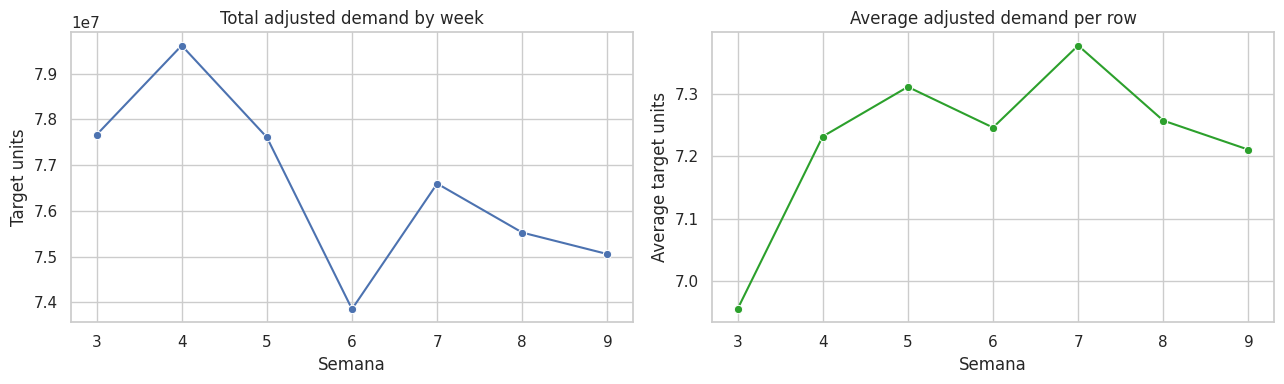

,Semana,rows,units_sold,units_returned,target_units,gross_sales,gross_returns,avg_target_units
0,3,11165207,"78,519,996.00","1,286,055.00","77,664,309.00","748,577,947.36","12,794,465.12",6.96
1,4,11009593,"80,509,571.00","1,322,852.00","79,618,866.00","755,607,344.22","13,371,044.81",7.23
2,5,10615397,"78,450,353.00","1,220,967.00","77,610,637.00","727,925,231.92","12,336,363.37",7.31
3,6,10191837,"74,753,832.00","1,321,510.00","73,851,129.00","701,524,061.85","12,886,385.28",7.25
4,7,10382849,"77,548,038.00","1,417,450.00","76,597,014.00","721,662,484.79","13,693,831.37",7.38
5,8,10406868,"76,497,828.00","1,452,369.00","75,525,105.00","713,412,752.58","13,885,240.31",7.26
6,9,10408713,"75,991,700.00","1,641,371.00","75,054,450.00","715,954,667.37","13,257,387.07",7.21


In [9]:
weekly = con.sql(f"""
SELECT
    Semana,
    COUNT(*) AS rows,
    SUM(Venta_uni_hoy) AS units_sold,
    SUM(Dev_uni_proxima) AS units_returned,
    SUM(Demanda_uni_equil) AS target_units,
    SUM(Venta_hoy) AS gross_sales,
    SUM(Dev_proxima) AS gross_returns,
    AVG(Demanda_uni_equil) AS avg_target_units
FROM read_csv('{TRAIN}', sample_size=10000)
GROUP BY Semana
ORDER BY Semana
""").df()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=weekly, x="Semana", y="target_units", marker="o", ax=axes[0])
axes[0].set_title("Total adjusted demand by week")
axes[0].set_ylabel("Target units")
sns.lineplot(data=weekly, x="Semana", y="avg_target_units", marker="o", color="tab:green", ax=axes[1])
axes[1].set_title("Average adjusted demand per row")
axes[1].set_ylabel("Average target units")
plt.tight_layout()
plt.show()

weekly

## 6. Largest products, channels, and states

These cuts show where volume is concentrated. They are also natural feature groups for validation and error analysis.

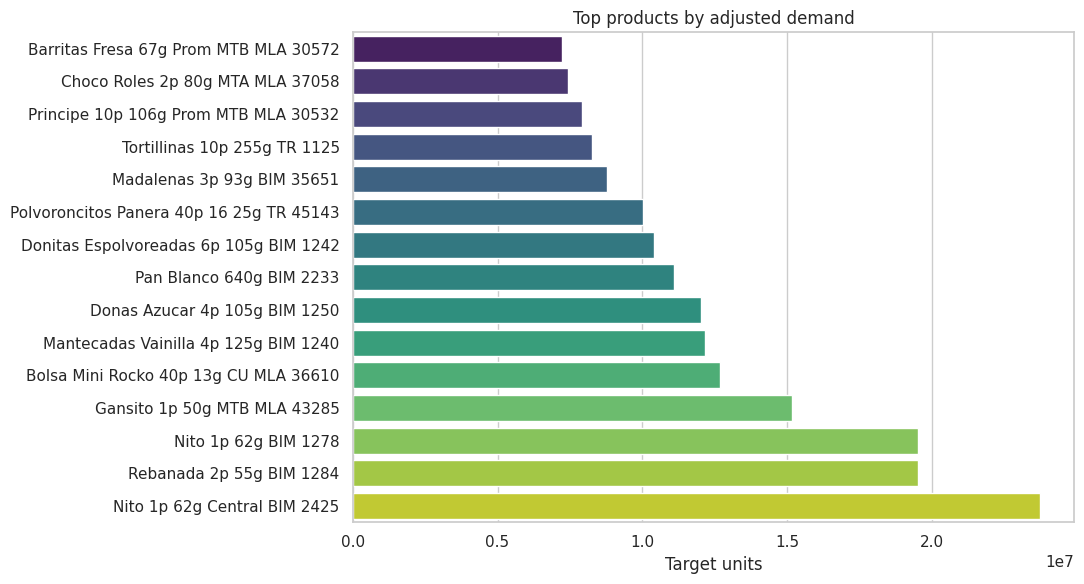

,Producto_ID,NombreProducto,rows,target_units,avg_target_units
0,2425,Nito 1p 62g Central BIM 2425,944518,"23,728,674.00",25.12
1,1284,Rebanada 2p 55g BIM 1284,1670190,"19,539,579.00",11.70
2,1278,Nito 1p 62g BIM 1278,1398090,"19,536,596.00",13.97
3,43285,Gansito 1p 50g MTB MLA 43285,1209450,"15,157,951.00",12.53
4,36610,Bolsa Mini Rocko 40p 13g CU MLA 36610,275957,"12,680,243.00",45.95
5,1240,Mantecadas Vainilla 4p 125g BIM 1240,2146655,"12,167,245.00",5.67
6,1250,Donas Azucar 4p 105g BIM 1250,1860488,"12,017,064.00",6.46
7,2233,Pan Blanco 640g BIM 2233,1975550,"11,101,761.00",5.62
8,1242,Donitas Espolvoreadas 6p 105g BIM 1242,2043864,"10,389,254.00",5.08
9,45143,Polvoroncitos Panera 40p 16 25g TR 45143,196867,"10,008,491.00",50.84


In [10]:
top_products = con.sql(f"""
WITH product_demand AS (
    SELECT
        Producto_ID,
        COUNT(*) AS rows,
        SUM(Demanda_uni_equil) AS target_units,
        AVG(Demanda_uni_equil) AS avg_target_units
    FROM read_csv('{TRAIN}', sample_size=10000)
    GROUP BY Producto_ID
)
SELECT
    pd.Producto_ID,
    p.NombreProducto,
    pd.rows,
    pd.target_units,
    pd.avg_target_units
FROM product_demand AS pd
LEFT JOIN read_csv('{PRODUCTS}', sample_size=10000) AS p USING (Producto_ID)
ORDER BY pd.target_units DESC
LIMIT 15
""").df()

plt.figure(figsize=(11, 6))
plot_df = top_products.sort_values("target_units", ascending=True)
sns.barplot(data=plot_df, x="target_units", y="NombreProducto", hue="NombreProducto", palette="viridis", legend=False)
plt.title("Top products by adjusted demand")
plt.xlabel("Target units")
plt.ylabel("")
plt.tight_layout()
plt.show()

top_products

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

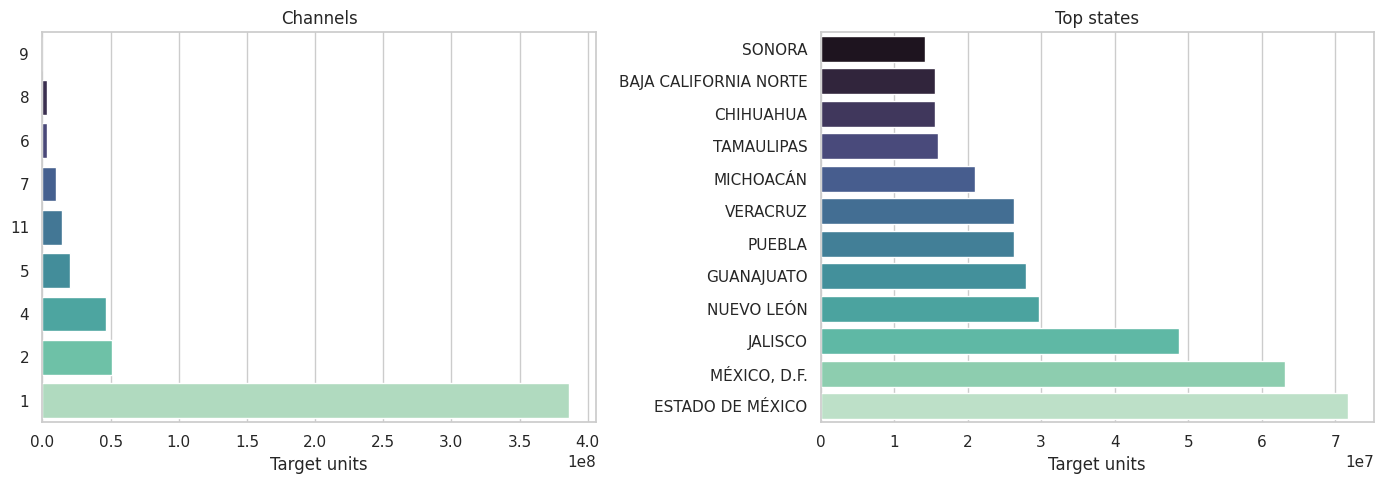

,cut,label,rows,target_units,avg_target_units
6,channel,1,67435217,"386,646,625.00",5.73
8,channel,2,839496,"51,384,359.00",61.21
7,channel,4,3757773,"46,468,113.00",12.37
2,channel,5,145818,"19,891,458.00",136.41
1,channel,11,982295,"14,589,584.00",14.85
5,channel,7,671128,"10,249,097.00",15.27
0,channel,6,281389,"3,549,277.00",12.61
4,channel,8,66970,"3,109,500.00",46.43
3,channel,9,378,"33,497.00",88.62
14,state,ESTADO DE MÉXICO,10880542,"71,685,681.00",6.59


In [11]:
channel_state_query = f"""
SELECT
    'channel' AS cut,
    CAST(Canal_ID AS VARCHAR) AS label,
    COUNT(*) AS rows,
    SUM(Demanda_uni_equil) AS target_units,
    AVG(Demanda_uni_equil) AS avg_target_units
FROM read_csv('{TRAIN}', sample_size=10000)
GROUP BY Canal_ID
UNION ALL
SELECT
    'state' AS cut,
    COALESCE(ts.State, 'UNKNOWN') AS label,
    COUNT(*) AS rows,
    SUM(t.Demanda_uni_equil) AS target_units,
    AVG(t.Demanda_uni_equil) AS avg_target_units
FROM read_csv('{TRAIN}', sample_size=10000) AS t
LEFT JOIN read_csv('{TOWN_STATE}', sample_size=10000) AS ts USING (Agencia_ID)
GROUP BY ts.State
"""
channel_state = con.sql(channel_state_query).df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cut, title in zip(axes, ["channel", "state"], ["Channels", "Top states"]):
    plot_df = (
        channel_state[channel_state["cut"] == cut]
        .sort_values("target_units", ascending=False)
        .head(12)
        .sort_values("target_units", ascending=True)
    )
    sns.barplot(data=plot_df, x="target_units", y="label", hue="label", palette="mako", legend=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Target units")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

channel_state.sort_values(["cut", "target_units"], ascending=[True, False]).head(20)

## 7. Train/test coverage check

Before modeling, check whether test IDs include unseen agencies, clients, products, routes, or channels compared with train.

In [12]:
key_columns = ["Agencia_ID", "Canal_ID", "Ruta_SAK", "Cliente_ID", "Producto_ID"]
coverage_rows = []
for column in key_columns:
    result = con.sql(f"""
        WITH
        train_keys AS (
            SELECT DISTINCT {column} AS key_value
            FROM read_csv('{TRAIN}', sample_size=10000)
        ),
        test_keys AS (
            SELECT DISTINCT {column} AS key_value
            FROM read_csv('{TEST}', sample_size=10000)
        ),
        test_only AS (
            SELECT key_value FROM test_keys
            EXCEPT
            SELECT key_value FROM train_keys
        ),
        train_only AS (
            SELECT key_value FROM train_keys
            EXCEPT
            SELECT key_value FROM test_keys
        )
        SELECT
            '{column}' AS key_column,
            (SELECT COUNT(*) FROM train_keys) AS train_unique,
            (SELECT COUNT(*) FROM test_keys) AS test_unique,
            (SELECT COUNT(*) FROM test_only) AS test_only_unique,
            (SELECT COUNT(*) FROM train_only) AS train_only_unique
    """).df().iloc[0].to_dict()
    coverage_rows.append(result)

coverage = pd.DataFrame(coverage_rows)
coverage["test_only_pct"] = coverage["test_only_unique"] / coverage["test_unique"]
coverage

,key_column,train_unique,test_unique,test_only_unique,train_only_unique,test_only_pct
0,Agencia_ID,552,552,0,0,0.00
1,Canal_ID,9,9,0,0,0.00
2,Ruta_SAK,3603,2608,17,1012,0.01
3,Cliente_ID,880604,745164,9663,145103,0.01
4,Producto_ID,1799,1522,34,311,0.02
